# Sanity 3: Deep Linear Residual Condition Number
Tracks conditioning growth across depth for two initialization scales.

sigma=0.02: final cond=5.357e+00
sigma=0.1: final cond=7.018e+04


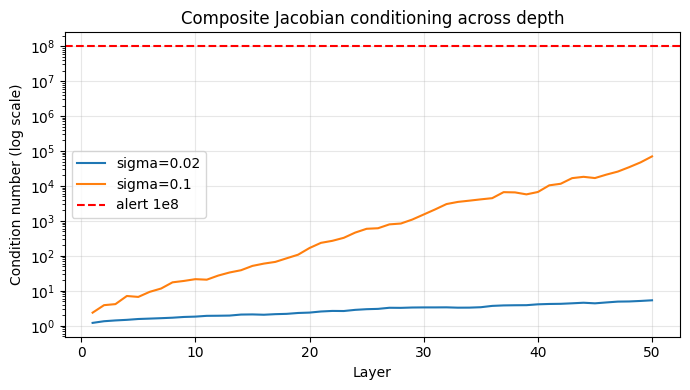

In [1]:
import torch
import matplotlib.pyplot as plt
from homeomorphism import jacobian

torch.manual_seed(0)
d, L = 16, 50
sigmas = [0.02, 0.1]

plt.figure(figsize=(7, 4))
for sigma in sigmas:
    J_total = torch.eye(d)
    conds = []
    for _ in range(L):
        W = torch.randn(d, d) * sigma

        def phi(h_seq):
            return h_seq + h_seq @ W.T

        h0 = torch.randn(1, d, dtype=torch.float32)
        bj = jacobian.build_jacobian(phi, h0, scope='diagonal')
        J_layer = bj[(0, 0)]
        J_total = J_layer @ J_total
        conds.append(float(torch.linalg.cond(J_total).item()))

    plt.plot(range(1, L + 1), conds, label=f'sigma={sigma}')
    print(f'sigma={sigma}: final cond={conds[-1]:.3e}')

plt.yscale('log')
plt.axhline(1e8, color='red', linestyle='--', label='alert 1e8')
plt.xlabel('Layer')
plt.ylabel('Condition number (log scale)')
plt.title('Composite Jacobian conditioning across depth')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()